In [17]:
import os
import sys
parent_dir = os.path.abspath(os.path.join(os.path.join(os.getcwd(), ".."), ".."))
sys.path.append(parent_dir)

import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

from data_generation.simulations.grid import *

In [18]:
bounds = np.array([[0, 10], [0, 10]])
numbercells = 30
cell_centers = np.array([[2.80643821, 4.35584996],
       [3.15023116, 0.30324409],
       [0.70956174, 6.68119224]])
seed = None
grid = VoronoiGrid(bounds, numbercells, cell_centers=cell_centers)

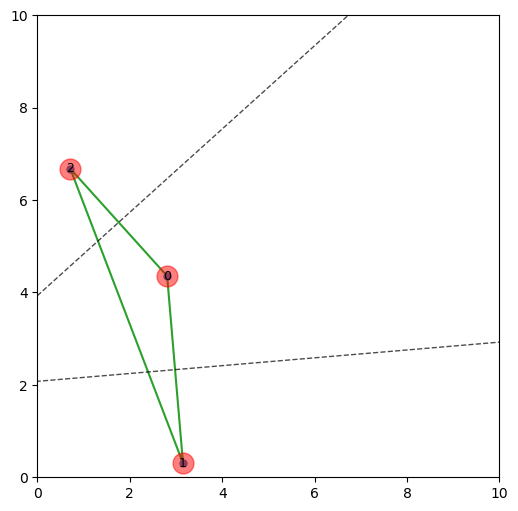

In [19]:
fig = voronoi_plot_2d(grid.voronoi, show_vertices=True, line_colors='black', line_width=1, line_alpha=0.7, point_size=10)
fig.set_size_inches(6, 6)
plt.xlim(bounds[0, 0], bounds[0, 1])
plt.ylim(bounds[1, 0], bounds[1, 1])
plt.gca().set_aspect('equal', adjustable='box')
points = grid.voronoi.points

plt.triplot(points[:,0], points[:,1], grid.delaunay.simplices)
for i, (x, y) in enumerate(points):
    plt.text(x, y, str(i), fontsize=9, ha='center', va='center', color='black')
plt.plot(points[:,0], points[:,1], 'o', markersize=15, color='red', alpha=0.5, label='Points')

plt.show()

In [20]:
grid.voronoi.points[0]

array([2.80643821, 4.35584996])

In [21]:
grid.get_cell_index(grid.voronoi.points[0]) in [9,0,3]

True

In [22]:
for (i, j), ridge_vertex_ids in zip(grid.voronoi.ridge_points, grid.voronoi.ridge_vertices):
    print(f"Ridge between points {i} and {j} has vertices {ridge_vertex_ids}")

Ridge between points 0 and 1 has vertices [-1, 0]
Ridge between points 0 and 2 has vertices [-1, 0]
Ridge between points 1 and 2 has vertices [-1, 0]


In [23]:
grid.get_neighbors()

{0: [1, 2], 1: [0], 2: [0]}

In [24]:
vor = grid.voronoi
for (i, j), ridge_vertex_ids in zip(vor.ridge_points, vor.ridge_vertices):
    
    ridge_vertices = []
    for idx in ridge_vertex_ids:
        if idx == -1:
            ridge_vertices.append('inf')
        else:
            ridge_vertices.append(vor.vertices[idx])

    print(f"Ridge between points {i} and {j}: vertices {ridge_vertices}")

Ridge between points 0 and 1: vertices ['inf', array([-2.27239486,  1.88411417])]
Ridge between points 0 and 2: vertices ['inf', array([-2.27239486,  1.88411417])]
Ridge between points 1 and 2: vertices ['inf', array([-2.27239486,  1.88411417])]


In [25]:
list(enumerate(grid.voronoi.points))

[(0, array([2.80643821, 4.35584996])),
 (1, array([3.15023116, 0.30324409])),
 (2, array([0.70956174, 6.68119224]))]

In [26]:
grid.kdtree.query(np.array([5,5]))

(2.2861851632315364, np.int64(0))

In [27]:
vv = grid.voronoi.vertices[grid.voronoi.ridge_vertices[0]]

In [28]:
from matplotlib import path
p = path.Path(vv)  # square with legs length 1 and bottom left corner at the origin
p.contains_point((.5, .5))


False

In [29]:
int(np.random.SeedSequence().generate_state(1)[0])


4291982473

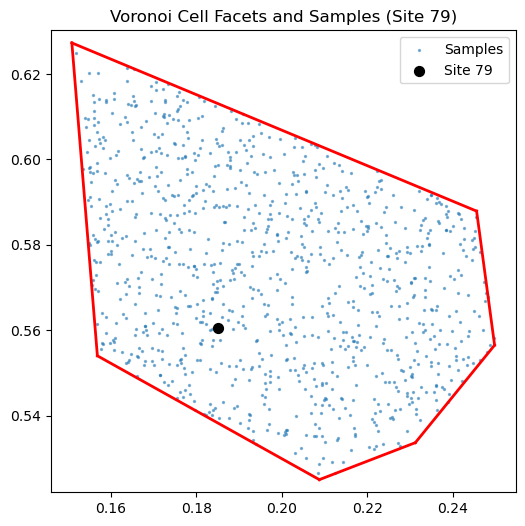

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, KDTree

def dirichlet_random_point(vertices):
    """Uniform sample a point from the simplex defined by 'vertices'."""
    m, d = vertices.shape
    y = -np.log(np.random.rand(m))
    bary = y / np.sum(y)
    return bary @ vertices

class VoronoiCellSampler2D:
    def __init__(self, sites):
        self.sites = np.asarray(sites)
        self.vor = Voronoi(self.sites)
        self._cell_data = {}

    def _compute_cell_facets(self, i):
        """For 2D, compute facets as line segments and triangle areas for sampling."""
        region_index = self.vor.point_region[i]
        region = self.vor.regions[region_index]
        if -1 in region:
            raise ValueError(f"Voronoi cell {i} is unbounded.")
        facets = []
        for (p, q), rv in zip(self.vor.ridge_points, self.vor.ridge_vertices):
            if i not in (p, q):
                continue
            j = q if p == i else p
            v0, v1 = self.vor.vertices[rv]
            # height from site to bisector
            height = np.linalg.norm(self.sites[j] - self.sites[i]) / 2.0
            # facet length
            length = np.linalg.norm(v1 - v0)
            # triangle area = 0.5 * base * height
            tri_area = 0.5 * length * height
            facets.append({'vertices': np.array([v0, v1]), 'area': tri_area})
        self._cell_data[i] = facets
        return facets

    def sample_point_in_cell(self, i):
        """Uniformly sample a point from the 2D Voronoi cell of site i."""
        if i not in self._cell_data:
            facets = self._compute_cell_facets(i)
        else:
            facets = self._cell_data[i]
        areas = np.array([f['area'] for f in facets])
        idx = np.random.choice(len(facets), p=areas / areas.sum())
        v0, v1 = facets[idx]['vertices']
        # triangle vertices: site, v0, v1
        triangle = np.vstack([self.sites[i], v0, v1])
        return dirichlet_random_point(triangle)

# Generate 100 random sites and sampler
np.random.seed()
sites = np.random.rand(100, 2)
sampler = VoronoiCellSampler2D(sites)

# Pick a random site
i = np.random.choice(len(sites))
facets = sampler._compute_cell_facets(i)

# Sample 1000 points from its cell
points = np.array([sampler.sample_point_in_cell(i) for _ in range(1000)])

# Plot
plt.figure(figsize=(6,6))
plt.scatter(points[:,0], points[:,1], s=2, alpha=0.5, label='Samples')
for f in facets:
    v0, v1 = f['vertices']
    plt.plot([v0[0], v1[0]], [v0[1], v1[1]], 'r-', linewidth=2)
plt.scatter([sites[i,0]], [sites[i,1]], c='k', s=50, label=f'Site {i}')
plt.title(f'Voronoi Cell Facets and Samples (Site {i})')
plt.axis('equal')
plt.legend()
plt.show()


In [32]:
from scipy.spatial import KDTree, Voronoi, ConvexHull

def dirichlet_random_point(vertices):
    """
    Sample uniformly from the simplex defined by `vertices`.
    `vertices` is an (m+1) x d array of simplex vertices.
    """
    m_plus1, d = vertices.shape
    # sample exponential(1) variates
    y = -np.log(np.random.rand(m_plus1))
    bary = y / np.sum(y)
    return bary @ vertices

class VoronoiCellSampler:
    def __init__(self, sites):
        """
        sites: (n x d) array of site coordinates
        """
        self.sites = np.asarray(sites)
        self.n, self.d = self.sites.shape
        # k-d tree for nearest neighbor queries
        self.kdtree = KDTree(self.sites)
        # full Voronoi diagram
        self.vor = Voronoi(self.sites)
        # storage for per-site facet info
        self._cell_data = {}

    def _compute_cell_facets(self, i):
        """
        For site index i, compute each facet (ridge) of its Voronoi cell,
        the facet vertices, the height (distance from site to facet), and
        the cone volume = (area of facet * height / d).
        """
        region_index = self.vor.point_region[i]
        region = self.vor.regions[region_index]
        if -1 in region:
            raise ValueError(f"Voronoi cell {i} is unbounded; cannot sample.")

        facets = []
        # iterate over ridges
        for (p, q), ridge_vertices in zip(self.vor.ridge_points, self.vor.ridge_vertices):
            if i not in (p, q):
                continue
            j = q if p == i else p
            # the facet is the ridge between i and j
            verts = np.asarray([self.vor.vertices[v] for v in ridge_vertices])
            
            # compute facet "area" via convex hull in d-1 dims
            if len(verts) <= 2:
                # degenerate case: line segment
                if len(verts) == 2:
                    area = np.linalg.norm(verts[1] - verts[0])
                else:
                    area = 0.0
            else:
                hull = ConvexHull(verts)
                area = hull.volume  # for facets, hull.volume is the (d-1)-dim measure
            # height = distance from site to bisector hyperplane
            height = np.linalg.norm(self.sites[j] - self.sites[i]) / 2.0
            cone_volume = area * height / float(self.d)
            facets.append({
                'neighbor': j,
                'vertices': verts,
                'height': height,
                'cone_volume': cone_volume,
                'hull_simplices': verts[hull.simplices] if len(verts) > 2 else np.array([verts])  # simplices for sampling
            })
        # store
        self._cell_data[i] = facets
        return facets

    def sample_point_in_cell(self, i):
        """
        Sample a uniformly random point from Voronoi cell of site i.
        """
        if i not in self._cell_data:
            facets = self._compute_cell_facets(i)
        else:
            facets = self._cell_data[i]

        # collect weights
        vols = np.array([f['cone_volume'] for f in facets])
        total = vols.sum()
        if total <= 0:
            raise ValueError(f"Degenerate cell {i} with zero total cone volume.")
        # choose facet index
        idx = np.random.choice(len(facets), p=vols/total)
        f = facets[idx]
        # pick a random point on the facet via simplicial decomposition
        # hull_simplices: list of simplices, each (d x (d-1)) array
        # compute simplex volumes (in facet dims)
        simps = f['hull_simplices']  # array of (n_simplices, d, d-1)
        # flatten list of simplices
        simplices = simps.reshape(-1, f['vertices'].shape[1], f['vertices'].shape[1]-1)
        # compute weights
        simp_vols = np.array([ConvexHull(s).volume for s in simplices])
        simp_total = simp_vols.sum()
        simp_idx = np.random.choice(len(simp_vols), p=simp_vols/simp_total)
        simplex = simplices[simp_idx]
        # sample random point in simplex
        x_facet = dirichlet_random_point(simplex)
        # direction from site
        u = (x_facet - self.sites[i]) / f['height']
        # sample radius
        r = f['height'] * np.random.rand()**(1.0/self.d)
        return self.sites[i] + r * u

# Example usage:
# sites = np.random.rand(100, 2)\# 2D example
# sampler = VoronoiCellSampler(sites)
# x = sampler.sample_point_in_cell(i=5)

# Generate 100 random sites and sampler
np.random.seed()
sites = np.random.rand(100, 2)
sampler = VoronoiCellSampler(sites)

# Pick a random site
i = np.random.choice(len(sites))
facets = sampler._compute_cell_facets(i)

# Sample 1000 points from its cell
points = np.array([sampler.sample_point_in_cell(i) for _ in range(1000)])

# Plot
plt.figure(figsize=(6,6))
plt.scatter(points[:,0], points[:,1], s=2, alpha=0.5, label='Samples')
for f in facets:
    v0, v1 = f['vertices']
    plt.plot([v0[0], v1[0]], [v0[1], v1[1]], 'r-', linewidth=2)
plt.scatter([sites[i,0]], [sites[i,1]], c='k', s=50, label=f'Site {i}')
plt.title(f'Voronoi Cell Facets and Samples (Site {i})')
plt.axis('equal')
plt.legend()
plt.show()


ValueError: Voronoi cell 53 is unbounded; cannot sample.

In [39]:
import numpy as np
from scipy.spatial import KDTree, Voronoi, ConvexHull

def dirichlet_random_point(vertices):
    """
    Sample uniformly from the simplex defined by `vertices`.
    `vertices` is an (m+1) x d array of simplex vertices.
    """
    m_plus1, d = vertices.shape
    y = -np.log(np.random.rand(m_plus1))
    bary = y / np.sum(y)
    return bary @ vertices

class VoronoiCellSampler:
    def __init__(self, sites):
        self.sites = np.asarray(sites)
        self.n, self.d = self.sites.shape
        self.kdtree = KDTree(self.sites)
        self.vor = Voronoi(self.sites)
        self._cell_data = {}

    def _compute_cell_facets(self, i):
        region_index = self.vor.point_region[i]
        region = self.vor.regions[region_index]
        if -1 in region or len(region) == 0:
            raise ValueError(f"Voronoi cell {i} is unbounded or degenerate.")

        facets = []
        for (p, q), ridge_vertices in zip(self.vor.ridge_points, self.vor.ridge_vertices):
            if i not in (p, q):
                continue
            j = q if p == i else p
            if -1 in ridge_vertices:
                continue
            verts = np.asarray([self.vor.vertices[v] for v in ridge_vertices])
            if len(verts) < self.d:
                continue
            area = np.linalg.norm(np.cross(verts[1] - verts[0], verts[-1] - verts[0])) / 2.0 if self.d == 2 else ConvexHull(verts).volume
            height = np.linalg.norm(self.sites[j] - self.sites[i]) / 2.0
            cone_volume = area * height / float(self.d)
            facets.append({
                'neighbor': j,
                'vertices': verts,
                'height': height,
                'cone_volume': cone_volume,
                'simplices': [verts]
            })
        self._cell_data[i] = facets
        return facets

    def sample_point_in_cell(self, i):
        if i not in self._cell_data:
            facets = self._compute_cell_facets(i)
        else:
            facets = self._cell_data[i]

        vols = np.array([f['cone_volume'] for f in facets])
        total = vols.sum()
        if total <= 0:
            raise ValueError(f"Degenerate cell {i} with zero total cone volume.")
        idx = np.random.choice(len(facets), p=vols / total)
        f = facets[idx]
        simplex = f['simplices'][0]
        x_facet = dirichlet_random_point(simplex)
        u = (x_facet - self.sites[i]) / f['height']
        r = f['height'] * np.random.rand() ** (1.0 / self.d)
        return self.sites[i] + r * u

# Create 2D example and sample points from one Voronoi cell
np.random.seed(0)
sites = np.random.rand(100, 2)
sampler = VoronoiCellSampler(sites)
sampled_points = np.array([sampler.sample_point_in_cell(5) for _ in range(1000)])
sampled_points[:5]  # Show first few sampled points for verification



/tmp/ipykernel_771/506942978.py:38: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  area = np.linalg.norm(np.cross(verts[1] - verts[0], verts[-1] - verts[0])) / 2.0 if self.d == 2 else ConvexHull(verts).volume


ValueError: Degenerate cell 5 with zero total cone volume.

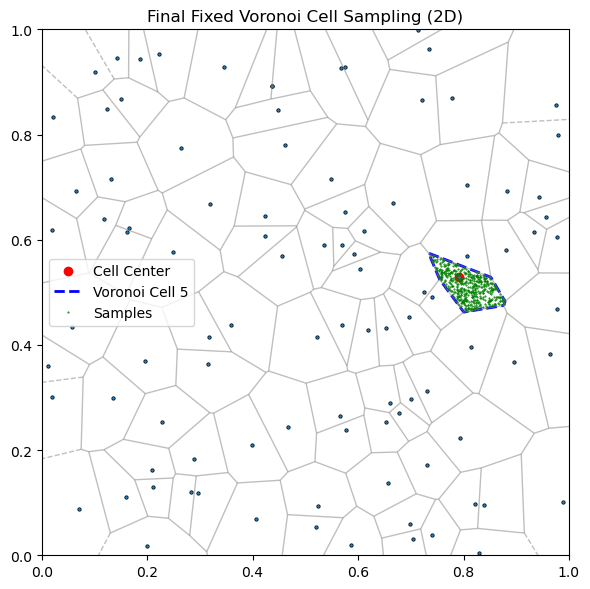

In [ ]:
import numpy as np
from scipy.spatial import KDTree, Voronoi, ConvexHull
from matplotlib.collections import LineCollection
from scipy.spatial import voronoi_plot_2d

def dirichlet_random_point(vertices):
    """
    Sample uniformly from the simplex defined by `vertices`.
    `vertices` is an m x d array of simplex vertices.
    """
    m, d = vertices.shape
    y = -np.log(np.random.rand(m))
    bary = y / np.sum(y) #barycentric coordinates
    # Return the point in the simplex as a linear combination of the vertices
    return bary @ vertices


class VoronoiCellSamplerFixed:
    def __init__(self, sites):
        self.sites = np.asarray(sites)
        self.n, self.d = self.sites.shape
        self.kdtree = KDTree(self.sites)
        self.vor = Voronoi(self.sites)
        self._cell_data = {}


    def _compute_cell_facets(self, i):
        region_index = self.vor.point_region[i]
        region = self.vor.regions[region_index] #vertex indices of the Voronoi cell
        if -1 in region or len(region) < self.d:
            # TODO: handle unbounded or degenerate cells
            raise ValueError(f"Voronoi cell {i} is unbounded or degenerate.")

        region_vertices = np.array([self.vor.vertices[v] for v in region])
        
        facets = []
        if self.d == 2:
            # In 2D, the region is a polygon; each edge is a facet
            n = len(region_vertices)
            for k in range(n):
                v1 = region_vertices[k]
                v2 = region_vertices[(k + 1) % n]
                edge = np.array([v1, v2])
                midpoint = (v1 + v2) / 2
                area = np.linalg.norm(v2 - v1)  # edge length
                height = np.linalg.norm(midpoint - self.sites[i])
                cone_volume = area * height / 2
                facets.append({
                    'vertices': edge,
                    'height': height,
                    'cone_volume': cone_volume,
                    'simplices': [edge]
                })
        else:
            # Higher dimensions: use convex hull facets
            hull = ConvexHull(region_vertices)
            for simplex_indices in hull.simplices:
                facet_vertices = region_vertices[simplex_indices]
                try:
                    facet_hull = ConvexHull(facet_vertices)
                    area = facet_hull.volume
                except:
                    continue # skip degenerate facets
                center = np.mean(facet_vertices, axis=0)
                height = np.linalg.norm(center - self.sites[i])
                cone_volume = area * height / self.d
                facets.append({
                    'vertices': facet_vertices,
                    'height': height,
                    'cone_volume': cone_volume,
                    'simplices': [facet_vertices]
                })

        if len(facets) == 0:
            raise ValueError(f"Could not compute valid facets for cell {i}.")
        self._cell_data[i] = facets
        return facets
    
    def sample_point_in_cell(self, i):
        """Uniformly sample a point from the Voronoi cell of site i.
        The idea is to decompose the cell into contes, one for each facet,
        and sample from these cones."""
        if i not in self._cell_data:
            facets = self._compute_cell_facets(i)
        else:
            facets = self._cell_data[i]

        vols = np.array([f['cone_volume'] for f in facets])
        total = vols.sum()
        if total <= 0:
            raise ValueError(f"Degenerate cell {i} with zero total cone volume.")
        idx = np.random.choice(len(facets), p=vols / total) #choose facet with probability based on the cone volumes
        f = facets[idx]
        simplex = f['simplices'][0]
        x_facet = dirichlet_random_point(simplex) #sample a point from the chosen facet
        u = (x_facet - self.sites[i]) #direction from site to facet point (could be normalized by f['height'])
        r = np.random.rand() ** (1.0 / self.d) #random radius on the direction (could be multiplied by f['height'])
        return self.sites[i] + r * u


In [92]:
import numpy as np

def generate_padded_sites(sites, bounds):
    """
    Given a set of sites and box bounds, generate mirrored padding sites by reflecting 
    across each axis-aligned face of the bounding box.

    Parameters:
    - sites: (n, d) array of original site coordinates.
    - bounds: list of (low, high) tuples for each dimension, e.g. [(0, 1), (0, 1)].

    Returns:
    - combined_sites: (n + m, d) array with original and padding sites.
    """
    sites = np.asarray(sites)
    d = sites.shape[1]
    mirrored_sites = []

    for axis in range(d):
        lo, hi = bounds[axis]

        # Mirror over lower bound
        lower_mirror = sites.copy()
        lower_mirror[:, axis] = 2 * lo - lower_mirror[:, axis]
        mirrored_sites.append(lower_mirror)

        # Mirror over upper bound
        upper_mirror = sites.copy()
        upper_mirror[:, axis] = 2 * hi - upper_mirror[:, axis]
        mirrored_sites.append(upper_mirror)

    # Stack original and mirrored
    all_sites = np.vstack([sites] + mirrored_sites)
    return all_sites

# Test in 2D
np.random.seed(2)
original_sites = np.random.rand(1000, 2)
bounds_2d = [(0, 1), (0, 1)]
padded_sites = generate_padded_sites(original_sites, bounds_2d)
padded_sites.shape  # should be (100 original + 2*2*100 mirrored = 500, 2)



(5000, 2)

In [133]:
import numpy as np
from scipy.spatial import KDTree, Voronoi, ConvexHull

def dirichlet_random_point(vertices):
    m, d = vertices.shape
    y = -np.log(np.random.rand(m))
    bary = y / np.sum(y)
    return bary @ vertices

def generate_padded_sites_optimized(sites, bounds, margin='auto'):
    """
    Generate padded sites by reflecting only those sites near the boundaries of the bounding box.

    Parameters:
    - sites: (n, d) array of original site coordinates
    - bounds: list of (min, max) tuples for each dimension
    - margin: float or 'auto' — margin threshold for reflecting sites near boundaries

    Returns:
    - padded_sites: (m, d) array including original and mirrored padding sites
    - is_original: (m,) boolean array indicating which are original sites
    """
    sites = np.asarray(sites)
    n, d = sites.shape
    bounds = np.asarray(bounds)

    if margin == 'auto':
        # Estimate nearest-neighbor distances using KDTree
        tree = KDTree(sites)
        distances, _ = tree.query(sites, k=2)  # first is the point itself
        margin = np.max(distances[:, 1])*1.5  # maximum nearest-neighbor distance

    padded_sites = [sites]
    is_original = [np.ones(n, dtype=bool)]

    for axis in range(d):
        min_b, max_b = bounds[axis]

        # Reflect near min boundary
        near_min_mask = sites[:, axis] - min_b <= margin
        near_min_sites = sites[near_min_mask].copy()
        if near_min_sites.size > 0:
            near_min_sites[:, axis] = 2 * min_b - near_min_sites[:, axis]
            padded_sites.append(near_min_sites)
            is_original.append(np.zeros(len(near_min_sites), dtype=bool))

        # Reflect near max boundary
        near_max_mask = max_b - sites[:, axis] <= margin
        near_max_sites = sites[near_max_mask].copy()
        if near_max_sites.size > 0:
            near_max_sites[:, axis] = 2 * max_b - near_max_sites[:, axis]
            padded_sites.append(near_max_sites)
            is_original.append(np.zeros(len(near_max_sites), dtype=bool))

    padded_sites = np.vstack(padded_sites)
    is_original = np.concatenate(is_original)
    return padded_sites, is_original

class VoronoiCellSamplerFixed:
    def __init__(self, sites, bounds):
        self.original_sites = np.asarray(sites)
        self.bounds = bounds
        self.sites, self.is_original = generate_padded_sites_optimized(self.original_sites, bounds, 1)
        self.n, self.d = self.sites.shape
        self.kdtree = KDTree(self.sites)
        self.vor = Voronoi(self.sites)
        self._cell_data = {}

    def _compute_cell_facets(self, i):
        region_index = self.vor.point_region[i]
        region = self.vor.regions[region_index]
        if -1 in region or len(region) < self.d:
            raise ValueError(f"Voronoi cell {i} is unbounded or degenerate.")
        region_vertices = np.array([self.vor.vertices[v] for v in region])
        facets = []
        if self.d == 2:
            n = len(region_vertices)
            for k in range(n):
                v1 = region_vertices[k]
                v2 = region_vertices[(k + 1) % n]
                edge = np.array([v1, v2])
                midpoint = (v1 + v2) / 2
                area = np.linalg.norm(v2 - v1)
                height = np.linalg.norm(midpoint - self.sites[i])
                cone_volume = area * height / 2
                facets.append({
                    'vertices': edge,
                    'height': height,
                    'cone_volume': cone_volume,
                    'simplices': [edge]
                })
        else:
            hull = ConvexHull(region_vertices)
            for simplex_indices in hull.simplices:
                facet_vertices = region_vertices[simplex_indices]
                try:
                    facet_hull = ConvexHull(facet_vertices)
                    area = facet_hull.volume
                except:
                    continue
                center = np.mean(facet_vertices, axis=0)
                height = np.linalg.norm(center - self.sites[i])
                cone_volume = area * height / self.d
                facets.append({
                    'vertices': facet_vertices,
                    'height': height,
                    'cone_volume': cone_volume,
                    'simplices': [facet_vertices]
                })
        if len(facets) == 0:
            raise ValueError(f"Could not compute valid facets for cell {i}.")
        self._cell_data[i] = facets
        return facets

    def sample_point_in_cell(self, i):
        if i not in self._cell_data:
            facets = self._compute_cell_facets(i)
        else:
            facets = self._cell_data[i]
        vols = np.array([f['cone_volume'] for f in facets])
        total = vols.sum()
        if total <= 0:
            raise ValueError(f"Degenerate cell {i} with zero total cone volume.")
        idx = np.random.choice(len(facets), p=vols / total)
        f = facets[idx]
        simplex = f['simplices'][0]
        x_facet = dirichlet_random_point(simplex)
        u = (x_facet - self.sites[i])
        r = np.random.rand() ** (1.0 / self.d)
        return self.sites[i] + r * u

# Example setup
np.random.seed(2)
original_sites = np.random.rand(100, 2)
bounds = [(0, 1), (0, 1)]
sampler = VoronoiCellSamplerFixed(original_sites, bounds)

# Identify only original site indices
original_indices = np.where(sampler.is_original)[0]



In [117]:
sampler.is_original

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False])

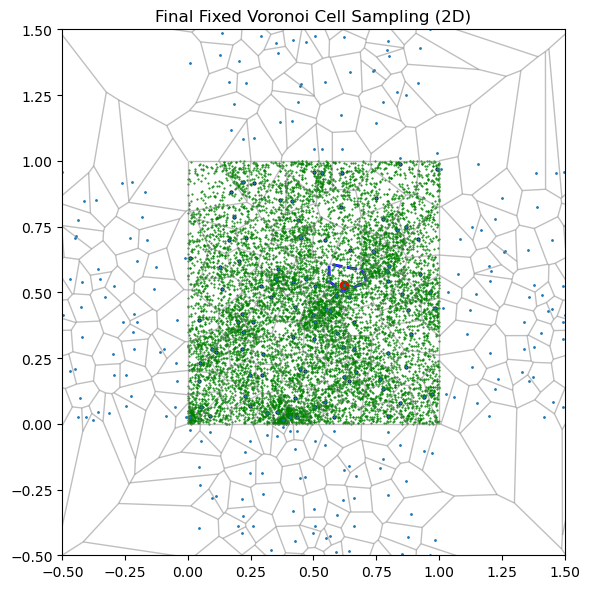

In [134]:
# Generate 100 random sites and sampler
sampler = VoronoiCellSamplerFixed(original_sites, bounds)

# Re-sample from cell 5
sampled_points = np.array([[sampler.sample_point_in_cell(i) for _ in range(100)] for i in original_indices] )

# Re-plot in 2D
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(original_sites[:, 0], original_sites[:, 1], 'ko', markersize=2)
ax.plot(original_sites[5, 0], original_sites[5, 1], 'ro', label='Cell Center')
region_index = sampler.vor.point_region[5]
region = sampler.vor.regions[region_index]
if -1 not in region:
    polygon = [sampler.vor.vertices[v] for v in region]
    polygon.append(polygon[0])
    poly = np.array(polygon)
    ax.plot(poly[:, 0], poly[:, 1], 'b--', lw=2, label='Voronoi Cell 5')
for i in range(len(original_sites)):
    ax.plot(sampled_points[i, :, 0], sampled_points[i, :, 1], 'g.', markersize=1, label='Samples')
voronoi_plot_2d(sampler.vor, ax=ax, show_vertices=False, line_colors='gray', line_width=1, line_alpha=0.5, point_size=2)

#ax.legend()
ax.set_title("Final Fixed Voronoi Cell Sampling (2D)")
ax.set_xlim([-0.5, 1.5])
ax.set_ylim([-0.5, 1.5])
#plt.axis("equal")
plt.tight_layout()
plt.show()
